# World Happiness Report (2019–2022) Analysis

**Project Objective:**  
The objective of this project is to apply concepts of **probability**, **descriptive statistics**, and **inferential statistics (hypothesis testing)** to analyze real-world data from the World Happiness Reports (2019–2022).

Through exploratory data analysis (EDA), we aim to:
- Understand distributions of key happiness factors
- Calculate important statistical measures (mean, median, variance, standard deviation)
- Perform correlation analysis between happiness score and influencing factors (like GDP, social support, life expectancy)
- Formulate and test hypotheses to draw meaningful inferences about global happiness patterns
- Visualize findings effectively to support statistical conclusions

---

## Step 1: Setting Up the Environment

- Installed required Python libraries:
  - `pandas` for data handling
  - `openpyxl` for reading Excel files
  - `matplotlib` and `seaborn` for data visualization
- Organized dataset files in the `/datasets` folder.

---

In [1]:
pip install pandas openpyxl matplotlib seaborn

---

## Step 2: Loading the Datasets

We load the World Happiness datasets for years 2019 to 2022.

- Ensure that all data files are placed inside a `datasets` folder
- Each file is named consistently, for example: `2019.csv`, `2020.csv`, `2021.csv`, `2022.csv`

---

In [2]:
import numpy as np
import pandas as pd
import pandas_profiling as pp
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import scipy.stats as stats

data_2019 = pd.read_csv('datasets/2019.csv')
data_2020 = pd.read_csv('datasets/2020.csv')
data_2021 = pd.read_csv('datasets/2021.csv')
data_2022 = pd.read_csv('datasets/2022.csv')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11536\1756400324.py:3: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling as pp


---
## Step 3: Datasets Dimensions and Heads
---

**2019 report**

---

In [3]:
print("Dataset Dimensions: {:,} columns and {:,} rows".format(data_2019.shape[1], data_2019.shape[0]))
data_2019.head()

Dataset Dimensions: 9 columns and 156 rows


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


---
**2020 report**

---

In [4]:
print("Dataset Dimensions: {:,} columns and {:,} rows".format(data_2020.shape[1], data_2020.shape[0]))
data_2020.head()

Dataset Dimensions: 20 columns and 153 rows


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.8087,0.031156,7.869766,7.747634,10.639267,0.954330,71.900825,0.949172,-0.059482,0.195445,1.972317,1.285190,1.499526,0.961271,0.662317,0.159670,0.477857,2.762835
1,Denmark,Western Europe,7.6456,0.033492,7.711245,7.579955,10.774001,0.955991,72.402504,0.951444,0.066202,0.168489,1.972317,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260,2.432741
2,Switzerland,Western Europe,7.5599,0.035014,7.628528,7.491272,10.979933,0.942847,74.102448,0.921337,0.105911,0.303728,1.972317,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946,2.350267
3,Iceland,Western Europe,7.5045,0.059616,7.621347,7.387653,10.772559,0.974670,73.000000,0.948892,0.246944,0.711710,1.972317,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541,2.460688
4,Norway,Western Europe,7.4880,0.034837,7.556281,7.419719,11.087804,0.952487,73.200783,0.955750,0.134533,0.263218,1.972317,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101,2.168266


---
**2021 report**

---

In [5]:
print("Dataset Dimensions: {:,} columns and {:,} rows".format(data_2021.shape[1], data_2021.shape[0]))
data_2021.head()

Dataset Dimensions: 20 columns and 149 rows


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


---
**2022 report**

---

In [5]:
print("Dataset Dimensions: {:,} columns and {:,} rows".format(data_2022.shape[1], data_2022.shape[0]))
data_2022.head()

Dataset Dimensions: 12 columns and 147 rows


,RANK,Country,Happiness score,Whisker-high,Whisker-low,Dystopia (1.83) + residual,Explained by: GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
0,1,Finland,"7,821","7,886","7,756","2,518","1,892","1,258","0,775","0,736","0,109","0,534"
1,2,Denmark,"7,636","7,710","7,563","2,226","1,953","1,243","0,777","0,719","0,188","0,532"
2,3,Iceland,"7,557","7,651","7,464","2,320","1,936","1,320","0,803","0,718","0,270","0,191"
3,4,Switzerland,"7,512","7,586","7,437","2,153","2,026","1,226","0,822","0,677","0,147","0,461"
4,5,Netherlands,"7,415","7,471","7,359","2,137","1,945","1,206","0,787","0,651","0,271","0,419"


---
## Step 4: Cleaning and Merging Happiness Report Data

- We standardize the column names for each year.
- We convert commas to dots if needed and make sure numbers are properly read as floats.
- We remove garbage rows (rows with country names missing) and drop rows where important values are missing.
- We calculate quartiles and claasify each row accordingly.
- We add years to each data entry.
- Then, we combine all years into a single clean dataset.
---

In [17]:
# standardizing column names
# This function takes the relevant report dataset and year in order to parse the data into a usable format
def parse_report(report_df, year):
    if year == 2019:
        report_df.rename(columns={'Overall rank': 'Happiness Rank', 'Country or region': 'Country',
                                  'Score': 'Happiness Score', 'GDP per capita': 'GDP per capita', 
                                  'Social support': 'Family', 'Healthy life expectancy': 'Health',
                                  'Freedom to make life choices': 'Freedom', 
                                  'Perceptions of corruption': 'Trust'}, inplace=True)
    elif year == 2020:
        report_df.rename(columns={'Country name': 'Country', 'Ladder score': 'Happiness Score',
                                  'Logged GDP per capita': 'GDP per capita', 'Social support': 'Family',
                                  'Healthy life expectancy': 'Health', 'Freedom to make life choices': 'Freedom',
                                  'Generosity': 'Generosity', 'Perceptions of corruption': 'Trust'}, inplace=True)
    elif year == 2021:
        report_df.rename(columns={'Country name': 'Country', 'Ladder score': 'Happiness Score',
                                  'Logged GDP per capita': 'GDP per capita', 'Social support': 'Family',
                                  'Healthy life expectancy': 'Health', 'Freedom to make life choices': 'Freedom',
                                  'Generosity': 'Generosity', 'Perceptions of corruption': 'Trust'}, inplace=True)
    elif year == 2022:
        report_df.rename(columns={'RANK': 'Happiness Rank', 'Country': 'Country', 'Happiness score': 'Happiness Score',
                                  'Whisker-high': 'Whisker-high', 'Whisker-low': 'Whisker-low',
                                  'Explained by: GDP per capita': 'GDP per capita', 'Explained by: Social support': 'Family',
                                  'Explained by: Healthy life expectancy': 'Health', 'Explained by: Freedom to make life choices': 'Freedom',
                                  'Explained by: Generosity': 'Generosity', 'Explained by: Perceptions of corruption': 'Trust'}, inplace=True)
    
    df_cols = ['Country', 'Happiness Score', 'GDP per capita', 'Family', 'Health', 'Freedom', 'Generosity', 'Trust']
    df = report_df[df_cols].copy()

    # Fixing commas
    df['Happiness Score'] = df['Happiness Score'].astype(str).str.replace(',', '.')
    df['GDP per capita'] = df['GDP per capita'].astype(str).str.replace(',', '.')
    df['Happiness Score'] = pd.to_numeric(df['Happiness Score'], errors='coerce')
    df['GDP per capita'] = pd.to_numeric(df['GDP per capita'], errors='coerce')

    # Removing garbage rows and dropping rows with important values missing
    df = df[df['Country'].notna() & (df['Country'] != 'xx')]
    df = df.dropna(subset=['Happiness Score', 'GDP per capita'])
    
    # Calculate quartiles for the 'Happiness Score' and 'GDP per capita' columns and adding years to each data entry
    targets = ['Low', 'Low-Mid', 'Top-Mid', 'Top']
    df['Happiness Target'] = pd.qcut(df['Happiness Score'], len(targets), labels=targets)
    df['GDP Target'] = pd.qcut(df['GDP per capita'], len(targets), labels=targets)
    df['Year'] = year
    
    return df

---
**combining datasets**

---

In [18]:
report_data_list = [parse_report(data_2019, 2019)]
for repData, year in [(data_2020, 2020), (data_2021, 2021), (data_2022, 2022)]:
    report_data_list.append(parse_report(repData, year))

merged_data = pd.concat(report_data_list, ignore_index=True)

print("Combined Dataset Dimensions: {:,} columns and {:,} rows".format(merged_data.shape[1], merged_data.shape[0]))
merged_data.head()

Combined Dataset Dimensions: 11 columns and 604 rows


,Country,Happiness Score,GDP per capita,Family,Health,Freedom,Generosity,Trust,Happiness Target,GDP Target,Year
0,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,Top,Top,2019
1,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.41,Top,Top,2019
2,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,Top,Top,2019
3,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,Top,Top,2019
4,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,Top,Top,2019


---
**check the combined dataset for any missing values**

---

In [19]:
print('Missing Value Counts for Each Column\n' + '='*36)
print(merged_data.isnull().sum())

Missing Value Counts for Each Column
Country             0
Happiness Score     0
GDP per capita      0
Family              0
Health              0
Freedom             0
Generosity          0
Trust               0
Happiness Target    0
GDP Target          0
Year                0
dtype: int64


---
**converting to a csv file for backup**

---

In [20]:
merged_data.to_csv('cleaned_dataset.csv', index=False)

---
## Step 5: Exploratory Data Analysis

- Understand the Distributions and Calculate Basic Statistics
- Visualize the basic distribution and statistics of important columns
- Perform correlation analysis between Happiness Score and influencing factors and plotting heatmap to visualize
- Bird eye view of column disribution and correlations
---

---
**5.1 Describing dataset**

---

In [9]:
print("Describe Dataset:")
merged_data.describe()

Describe Dataset:


,Happiness Score,GDP per capita,Family,Year
count,604.000000,604.000000,604.000000,604.000000
mean,5.490278,5.256242,0.937024,2020.471854
std,1.095781,4.207743,0.275778,1.118606
min,2.404000,0.000000,0.000000,2019.000000
25%,4.705250,1.179000,0.778250,2019.000000
50%,5.507550,4.350821,0.896362,2020.000000
75%,6.229875,9.512602,1.106250,2021.000000
max,7.842000,11.647000,1.624000,2022.000000


---
**5.2 Plots**

---

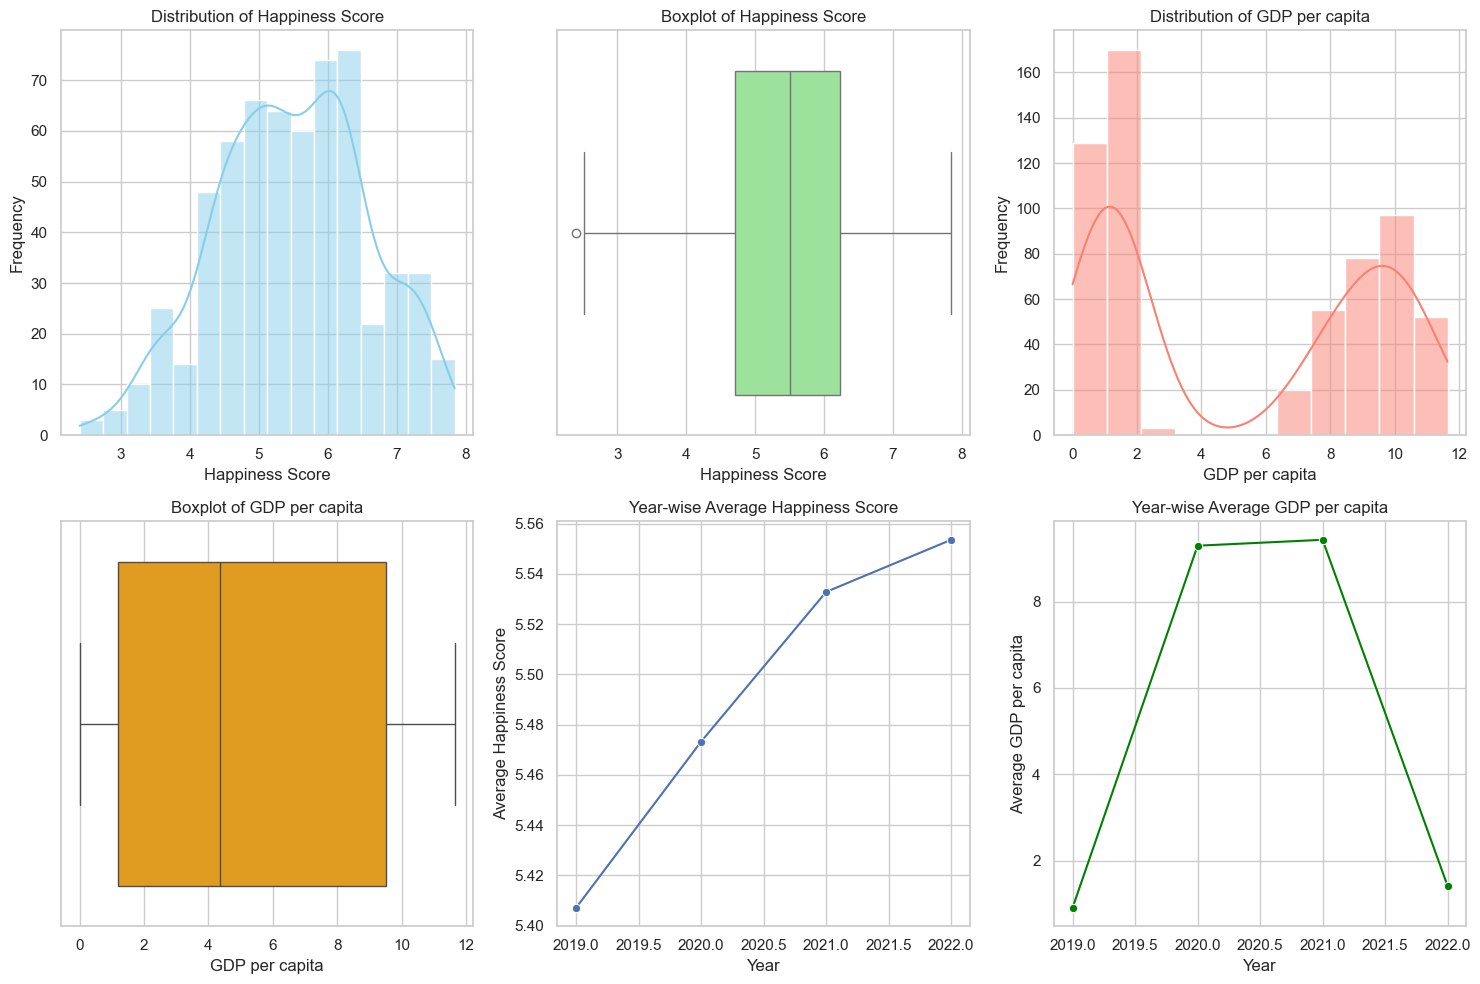

In [10]:
# Set a beautiful theme
sns.set(style="whitegrid")

# Create a 2x3 grid for the subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Histogram of Happiness Score
sns.histplot(merged_data['Happiness Score'], kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Happiness Score')
axes[0, 0].set_xlabel('Happiness Score')
axes[0, 0].set_ylabel('Frequency')

# 2. Boxplot of Happiness Score
sns.boxplot(x=merged_data['Happiness Score'], color='lightgreen', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Happiness Score')

# 3. Histogram of GDP per capita
sns.histplot(merged_data['GDP per capita'], kde=True, color='salmon', ax=axes[0, 2])
axes[0, 2].set_title('Distribution of GDP per capita')
axes[0, 2].set_xlabel('GDP per capita')
axes[0, 2].set_ylabel('Frequency')

# 4. Boxplot of GDP per capita
sns.boxplot(x=merged_data['GDP per capita'], color='orange', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of GDP per capita')

# 5. Year-wise average Happiness Score
yearly_happiness = merged_data.groupby('Year')['Happiness Score'].mean()
sns.lineplot(x=yearly_happiness.index, y=yearly_happiness.values, marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Year-wise Average Happiness Score')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Happiness Score')

# 6. Year-wise average GDP per capita
yearly_gdp = merged_data.groupby('Year')['GDP per capita'].mean()
sns.lineplot(x=yearly_gdp.index, y=yearly_gdp.values, marker='o', color='green', ax=axes[1, 2])
axes[1, 2].set_title('Year-wise Average GDP per capita')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Average GDP per capita')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

---
**5.3 Correlation heatmap**

---

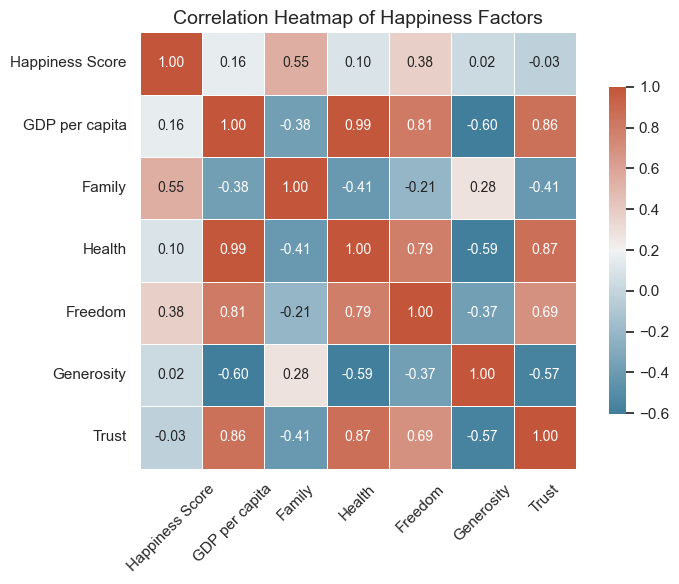

In [11]:
for col in ['Happiness Score', 'GDP per capita', 'Family', 'Health', 'Freedom', 'Generosity', 'Trust']:
    merged_data[col] = merged_data[col].astype(str).str.replace(',', '.')
    merged_data[col] = pd.to_numeric(merged_data[col], errors='coerce')

# Compute correlation matrix
corr_matrix = merged_data[['Happiness Score', 'GDP per capita', 'Family', 'Health', 'Freedom', 'Generosity', 'Trust']].corr()

cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Smaller size
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=cmap,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 10} 
)
plt.title('Correlation Heatmap of Happiness Factors', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


---
**5.4 Column distributions: A bird eye view**

---

<Figure size 600x600 with 0 Axes>

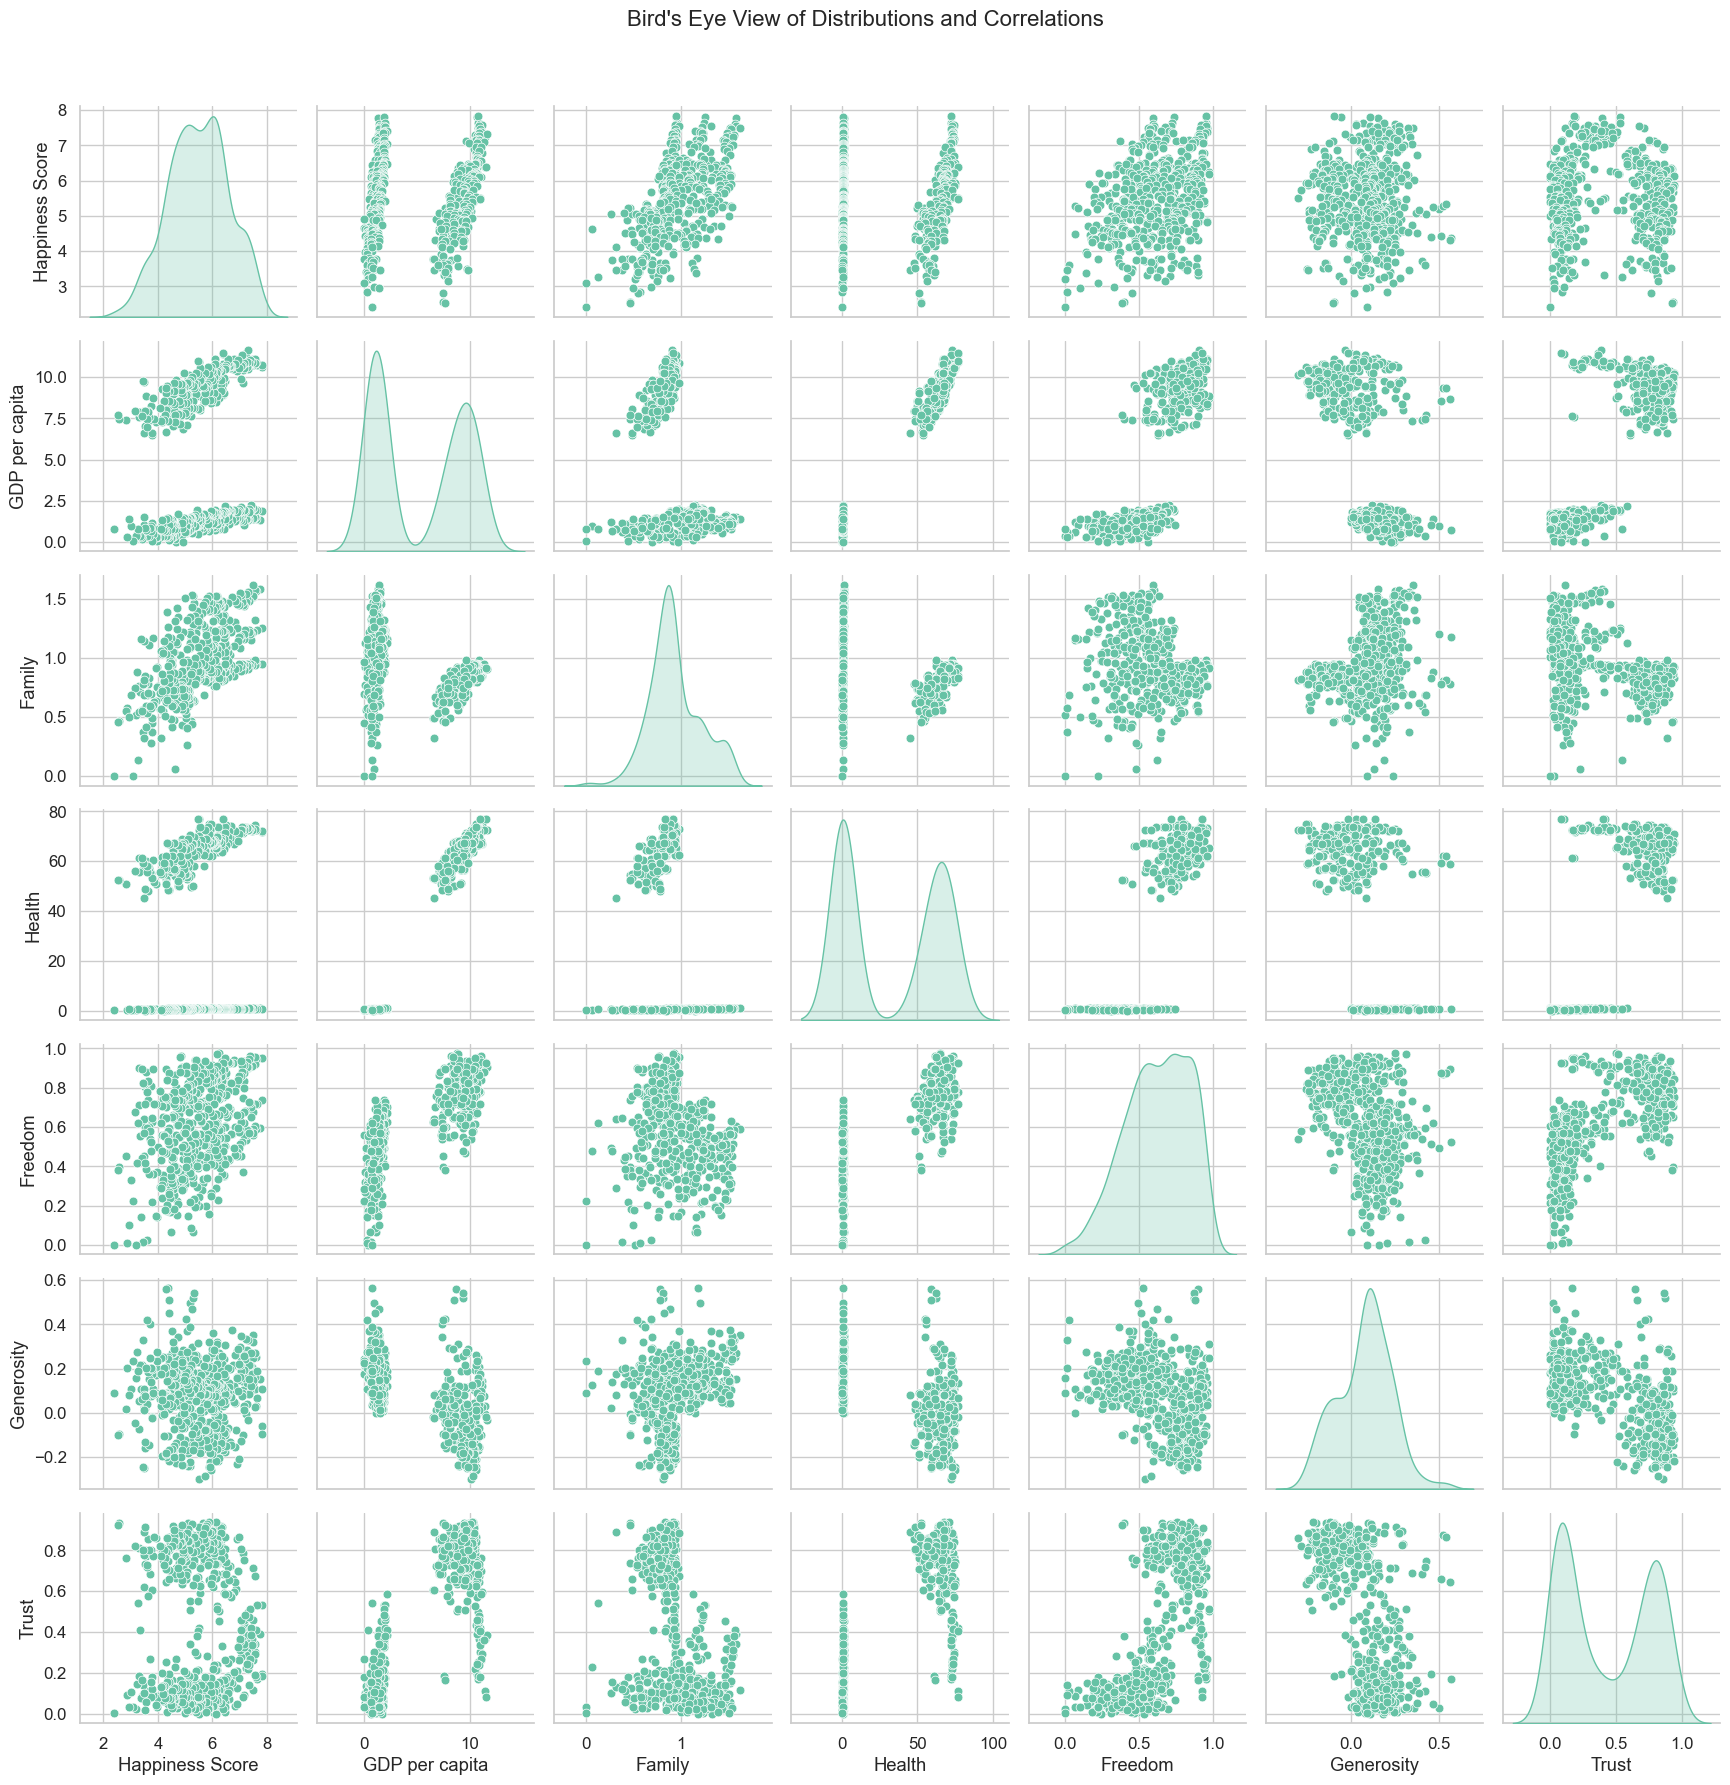

In [12]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)
plt.figure(figsize=(6, 6))

selected_columns = ['Happiness Score', 'GDP per capita', 'Family', 'Health', 'Freedom', 'Generosity', 'Trust']
pairplot = sns.pairplot(
    merged_data[selected_columns],
    diag_kind='kde',       
    plot_kws={"s": 40, "edgecolor": "w"}  
)
pairplot.fig.suptitle("Bird's Eye View of Distributions and Correlations", y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

---
## Step 6 Hypothesis Testing: 

### Hypothesis 1: Are people from richer countries significantly happier?

We want to test whether people living in richer countries (with higher GDP per capita) are significantly happier.

- **Null Hypothesis (H₀)**:  
There is no significant relationship between GDP per capita and Happiness Score.

- **Alternate Hypothesis (H₁)**:  
There is a significant positive relationship between GDP per capita and Happiness Score.

### Choice of Statistical Test:
We are comparing the happiness scores between two groups of countries:

- **Richer countries**: Defined as those with a GDP per capita greater than the median GDP per capita.
- **Poorer countries**: Defined as those with a GDP per capita less than or equal to the median GDP per capita.

Since we are comparing the means of happiness scores between two independent groups (richer and poorer countries), the appropriate statistical test is an Independent Samples t-test. This test checks whether there is a significant difference between the means of the two groups.

---

In [13]:
# Step 1: Define the threshold for richer vs poorer countries
median_gdp = merged_data['GDP per capita'].median()

# Split the data into two groups based on GDP per capita
richer_countries = merged_data[merged_data['GDP per capita'] > median_gdp]
poorer_countries = merged_data[merged_data['GDP per capita'] <= median_gdp]

# Step 2: Perform an independent samples t-test
t_stat, p_value = stats.ttest_ind(richer_countries['Happiness Score'], poorer_countries['Happiness Score'])

# Step 3: Interpret the results
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

# Step 4: Conclusion
if p_value < 0.10:
    print("Reject the null hypothesis: There is a significant difference in happiness between richer and poorer countries.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in happiness between richer and poorer countries.")


t-statistic: 0.277
p-value: 0.782
Fail to reject the null hypothesis: There is no significant difference in happiness between richer and poorer countries.


---
**The plot**

---

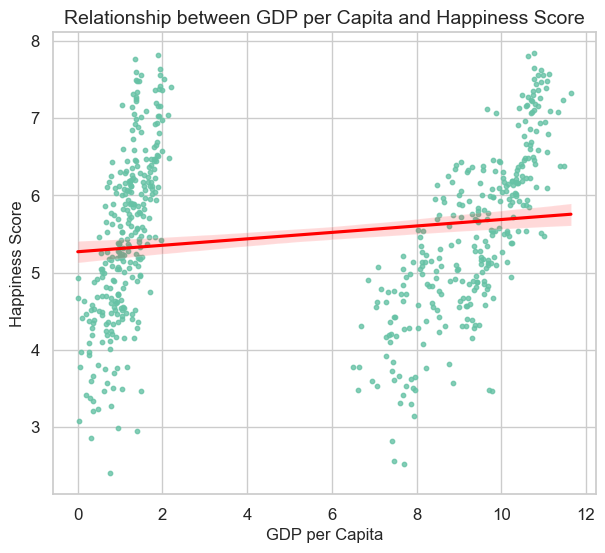

In [14]:
# Scatter plot with regression line
plt.figure(figsize=(7, 6))
sns.regplot(x='GDP per capita', y='Happiness Score', data=merged_data, scatter_kws={'s': 10}, line_kws={'color': 'red'})
plt.title("Relationship between GDP per Capita and Happiness Score", fontsize=14)
plt.xlabel("GDP per Capita", fontsize=12)
plt.ylabel("Happiness Score", fontsize=12)
plt.show()

---

### Hypothesis 2: Does family support increase happiness?

- **Null Hypothesis (H₀)**:  
There is no significant relationship between family support and happiness. (Family support does not influence happiness)

- **Alternate Hypothesis (H₁)**:  
There is a significant relationship between family support and happiness. (Family support increases happiness)

### Choice of Statistical Test:
We are examining the relationship between family support and happiness score.

Since both variables are continuous, the appropriate statistical test is Pearson's Correlation Coefficient. This test measures the linear relationship between two continuous variables. It quantifies the strength and direction of the relationship between family support and happiness score, providing a correlation coefficient and a p-value to assess statistical significance. If the correlation coefficient is significantly different from zero (p-value < 0.05), we can conclude that family support has a significant effect on happiness.

---

In [15]:
filtered_data = merged_data[['Family', 'Happiness Score']].dropna()

# Now calculate Pearson correlation
correlation, p_value = stats.pearsonr(filtered_data['Family'], filtered_data['Happiness Score'])

print(f"Pearson's Correlation Coefficient: {correlation}")
print(f"P-value: {p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis: family support has a significant effect on happiness.")
else:
    print("Failed  to reject the null hypothesis: family support has no a significant effect on happiness.")

Pearson's Correlation Coefficient: 0.5472745377813723
P-value: 1.730543983654288e-48
Reject the null hypothesis: family support has a significant effect on happiness.


---
**The plot**

---

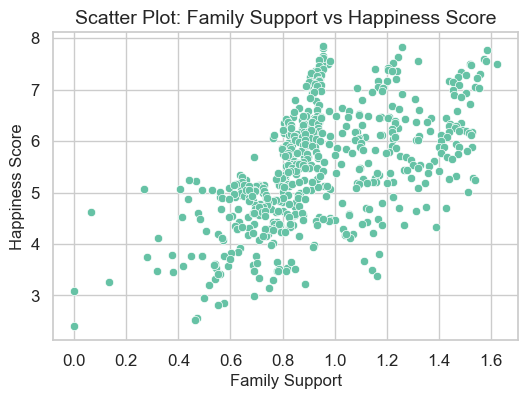

In [16]:
# Scatter plot to visualize the relationship between Family support and Happiness score
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Family', y='Happiness Score', data=merged_data)

# Adding titles and labels
plt.title("Scatter Plot: Family Support vs Happiness Score", fontsize=14)
plt.xlabel("Family Support", fontsize=12)
plt.ylabel("Happiness Score", fontsize=12)

plt.show()

### Conclusion

In this project, we investigated key factors influencing happiness across different countries, focusing specifically on the roles of **GDP per capita** and **family support**. Using statistical tests and visual exploration, we derived the following insights:

---

#### 1. Happiness and GDP per Capita
- **Hypothesis**: Are people from richer countries significantly happier?
- An **Independent Samples t-test** revealed a **t-statistic of 0.277** and a **p-value of 0.782** — well above the 0.05 significance threshold.
- **Interpretation**: We fail to reject the null hypothesis, suggesting that **being wealthier as a nation does not significantly impact happiness levels**.
- The scatter plot showed a **slight upward trend**, but with high variability, indicating that **money alone cannot buy happiness** at a national level.

---

#### 2. Happiness and Family Support
- **Hypothesis**: Does stronger family support correlate with higher happiness?
- A **Pearson correlation** produced a **coefficient of 0.547** and an extremely small **p-value (1.73e-48)**.
- **Interpretation**: We found a **moderate, statistically significant positive relationship** — **family support consistently elevates happiness scores** across nations.
- The scatter plot clearly illustrated a **stronger and more cohesive upward trend** compared to GDP.

---

### Key Takeaways
- **GDP per Capita**: Economic wealth shows only a weak association with happiness and is **not a reliable standalone predictor**.
- **Family Support**: Social and emotional support structures are **crucial pillars of happiness**, proving to be far more impactful than financial metrics.

---

### Final Thoughts
While wealth can create opportunities, it is **relationships, trust, and support systems** that truly fuel happiness. This analysis highlights the **power of human connection over material prosperity** — a story supported by both numbers and visuals.

Moving forward, policymakers aiming to enhance national well-being should look beyond GDP growth and invest in **strengthening family and community ties**, building a **happier, more resilient society**.

---
## Step 7: Pandas Profiling Report: Summary, Correlation Matrices, and Missing Value Information.
---

In [22]:
# Combined Happiness Reports Profiling Report
pp.ProfileReport(merged_data).to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 44.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]